# Análisis exploratorio para preprocesamiento
Revisión de valores faltantes, outliers, escalado y codificación del dataset de Airbnb Londres, como base para las decisiones de preprocesamiento del modelo.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../../data/processed/airprice_clean.csv")  

# Convertir price a número si viene como texto ("$120.00")
if "price" in df.columns and df["price"].dtype == "object":
    df["price"] = df["price"].str.replace(r"[$,]", "", regex=True).astype(float)

print(df.shape)
df.head()

(61617, 32)


,id,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms_num,bedrooms,beds,...,price_clean,bathrooms_num_missing,bedrooms_missing,beds_missing,minimum_nights_missing,reviews_per_month_missing,review_scores_rating_missing,host_response_rate_num_missing,host_acceptance_rate_num_missing,price_range
0,11551,Lambeth,51.46095,-0.11758,Entire rental unit,Entire home/apt,5,1.0,1.0,3.0,...,234.50,0,0,0,0,0,0,1,1,ALTO
1,13913,Islington,51.56861,-0.11270,Private room in rental unit,Private room,1,1.0,1.0,1.0,...,127.00,0,1,0,0,0,0,1,1,MEDIO
2,15400,Kensington and Chelsea,51.48780,-0.16813,Entire rental unit,Entire home/apt,2,1.0,1.0,1.0,...,137.50,0,0,0,0,0,0,1,1,MEDIO
3,17402,Westminster,51.52195,-0.14094,Entire rental unit,Entire home/apt,6,2.0,3.0,3.0,...,606.67,0,0,0,0,0,0,1,1,PREMIUM
4,513198,Lambeth,51.48875,-0.10934,Private room in rental unit,Private room,1,1.5,1.0,1.0,...,68.30,0,0,0,0,0,0,1,1,ECONOMICO


## 1. Valores faltantes

In [17]:
faltantes = (df.isna().mean() * 100).sort_values(ascending=False)
faltantes = faltantes[faltantes > 0]
print(faltantes.round(2))

if len(faltantes) > 0:
    faltantes.plot(kind="barh", figsize=(8, 6), title="% de valores faltantes por columna")
    plt.xlabel("%")
    plt.show()

Series([], dtype: float64)


## 2. Outliers
Detección con el método IQR (valores por fuera de Q1 − 1.5·IQR y Q3 + 1.5·IQR).

In [18]:
cols_num = df.select_dtypes(include="number").columns.drop(["id", "host_id"], errors="ignore")
cols_num = [c for c in cols_num if df[c].nunique() > 2]  # excluir flags binarios

resumen = []
for c in cols_num:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    n = ((df[c] < q1 - 1.5 * iqr) | (df[c] > q3 + 1.5 * iqr)).sum()
    resumen.append({"columna": c, "outliers": n, "%": round(n / len(df) * 100, 2)})

pd.DataFrame(resumen).sort_values("outliers", ascending=False)

,columna,outliers,%
5,beds,6993,11.35
8,number_of_reviews,6700,10.87
9,reviews_per_month,6192,10.05
10,review_scores_rating,5430,8.81
3,bathrooms_num,5293,8.59
6,minimum_nights,4991,8.10
2,accommodates,3819,6.20
12,price_clean,3692,5.99
0,latitude,3673,5.96
4,bedrooms,3182,5.16


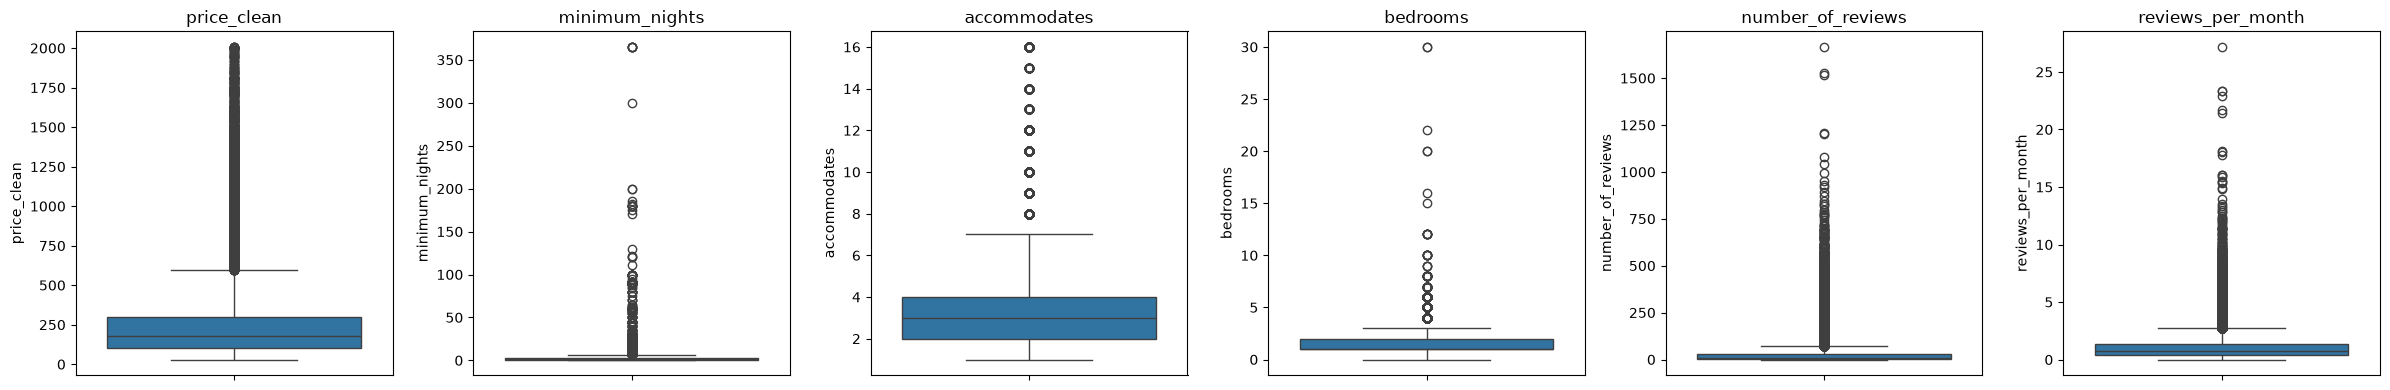

In [19]:
cols_box = ["price_clean", "minimum_nights", "accommodates", "bedrooms", "number_of_reviews", "reviews_per_month"]
fig, axes = plt.subplots(1, len(cols_box), figsize=(4 * len(cols_box), 4))
for ax, c in zip(np.atleast_1d(axes), cols_box):
    sns.boxplot(y=df[c], ax=ax)
    ax.set_title(c)
plt.tight_layout()
plt.show()

## 3. Escalado
Comparación de la distribución original frente a StandardScaler, MinMaxScaler y transformación logarítmica.

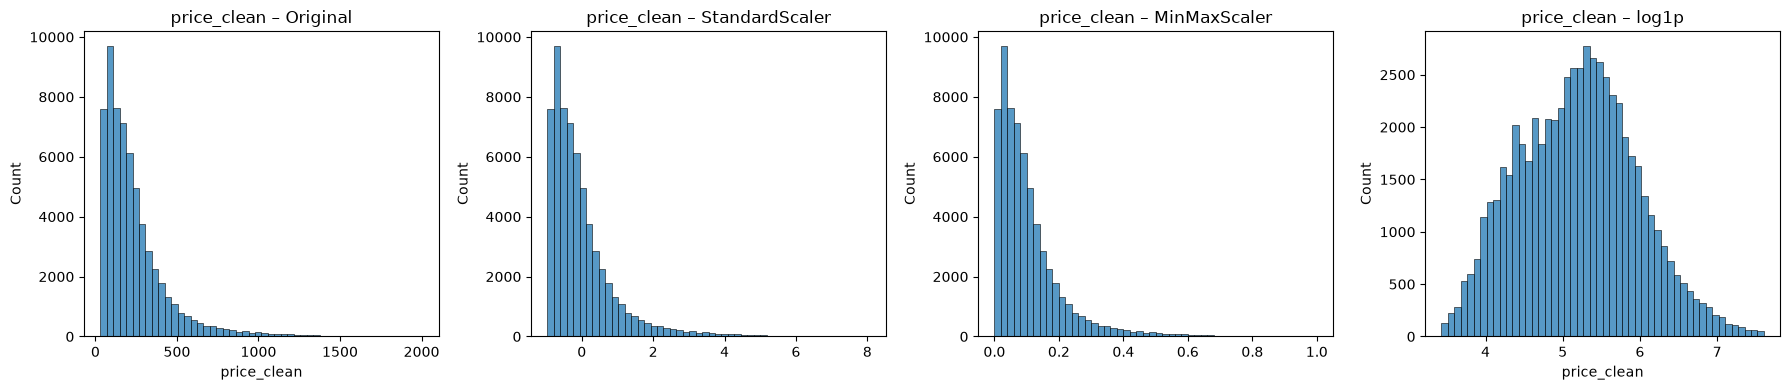

In [20]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

col = "price_clean"
x = df[[col]].dropna()

versiones = {
    "Original": x[col],
    "StandardScaler": StandardScaler().fit_transform(x).ravel(),
    "MinMaxScaler": MinMaxScaler().fit_transform(x).ravel(),
    "log1p": np.log1p(x[col]),
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (nombre, datos) in zip(axes, versiones.items()):
    sns.histplot(datos, bins=50, ax=ax)
    ax.set_title(f"{col} – {nombre}")
plt.tight_layout()
plt.show()

## 4. Codificación de variables categóricas

In [21]:
cols_cat = df.select_dtypes(include="object").columns
cardinalidad = df[cols_cat].nunique().sort_values()
print(cardinalidad)

baja = cardinalidad[cardinalidad <= 10].index.tolist()
alta = cardinalidad[cardinalidad > 10].index.tolist()
print("\nOne-hot (pocas categorías):", baja)
print("Frequency/target encoding (muchas categorías):", alta)

instant_bookable           1
host_is_superhost          3
host_identity_verified     3
room_type                  4
price_range                4
property_type             15
neighbourhood_cleansed    33
dtype: int64

One-hot (pocas categorías): ['instant_bookable', 'host_is_superhost', 'host_identity_verified', 'room_type', 'price_range']
Frequency/target encoding (muchas categorías): ['property_type', 'neighbourhood_cleansed']


C:\Users\willi\AppData\Local\Temp\ipykernel_13436\795722331.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_cat = df.select_dtypes(include="object").columns


In [22]:
# Ejemplo de one-hot con las columnas de baja cardinalidad
ejemplo_onehot = pd.get_dummies(df[baja], drop_first=True) if baja else pd.DataFrame()
print("Columnas generadas con one-hot:", ejemplo_onehot.shape[1])

# Ejemplo de frequency encoding con la primera de alta cardinalidad
if alta:
    c = alta[0]
    freq = df[c].map(df[c].value_counts(normalize=True))
    print(f"\nFrequency encoding de '{c}':")
    print(pd.DataFrame({c: df[c], f"{c}_freq": freq}).head())

Columnas generadas con one-hot: 10

Frequency encoding de 'property_type':
                 property_type  property_type_freq
0           Entire rental unit            0.436844
1  Private room in rental unit            0.111576
2           Entire rental unit            0.436844
3           Entire rental unit            0.436844
4  Private room in rental unit            0.111576


## 5. Conclusiones y decisiones de preprocesamiento

**Valores faltantes**
- El dataset limpio ya no tiene nulos, porque el ETL los imputó. Las columnas `*_missing` muestran cuánto faltaba originalmente: `bedrooms` ~22 %, `reviews_per_month` y `review_scores_rating` ~21.6 % (anuncios sin reseñas) y `beds` ~6.7 %.
- `host_response_rate_num` y `host_acceptance_rate_num` venían **100 % vacías** y quedaron en 0 para todos los registros, así que no aportan información. Se eliminan junto con sus flags.
- `instant_bookable` tiene un único valor (`UNKNOWN`). Es constante y se elimina.
- `has_reviews`, `reviews_per_month_missing` y `review_scores_rating_missing` son la misma información, así que basta con conservar `has_reviews`.

**Outliers**
- `price_clean` tiene una asimetría fuerte a la derecha (mediana ≈ 180, máximo ≈ 2007, skew ≈ 2.8). No se eliminan los valores altos porque son anuncios reales; se maneja con transformación logarítmica.
- `minimum_nights` llega hasta 365 aunque el percentil 99 es 30. Se recomienda recortarla (*capping*) en el p99.
- Los outliers de `latitude`/`longitude` son anuncios en zonas periféricas de Londres, no errores, así que se conservan.

**Escalado**
- `log1p(price_clean)` reduce la asimetría de ≈ 2.8 a ≈ 0.2, así que se recomienda modelar el precio en escala logarítmica.
- StandardScaler y MinMaxScaler no cambian la forma de la distribución. Sirven para modelos lineales o basados en distancia, pero no son necesarios para modelos de árboles.
- El scaler se ajusta solo con el conjunto de entrenamiento para evitar fuga de datos.

**Codificación**
- One-hot para variables de pocas categorías: `room_type`, `host_is_superhost`, `host_identity_verified`.
- `property_type` (15) y `neighbourhood_cleansed` (33): one-hot sigue siendo viable; otra opción es frequency o target encoding (este último con validación cruzada).
- `price_range` se deriva directamente de `price_clean` (cuartiles). **No debe usarse como variable predictora**, porque filtraría el objetivo. Solo sirve como target si se plantea el problema como clasificación.
